In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.core.interactiveshell import InteractiveShell # 这个对象设置所有行全部输出

# 设置该对象ast_node_interactivity属性的值为all，表示在notebook下每一行有输出的代码全部输出运算结果
InteractiveShell.ast_node_interactivity = "all" 

# 解决坐标轴刻度负号乱码
plt.rcParams['axes.unicode_minus'] = False

# 解决中文乱码问题
plt.rcParams['font.sans-serif'] = ['Simhei']
plt.style.use('ggplot')

In [2]:
# 数据准备
rowdata = {
    '颜色深度':[14.13,13.2,13.16,14.27,13.24,12.07,12.43,11.79,12.37,12.04],
    '酒精浓度': [5.64,4.28,5.68,4.80,4.22,2.76,3.94,3.1,2.12,2.6],
    '品种': [0,0,0,0,0,1,1,1,1,1] # 0 代表 “黑皮诺”，1 代表 “赤霞珠”
}

# 构建为dataframe对象
wine_data = pd.DataFrame(rowdata)
wine_data

,颜色深度,酒精浓度,品种
0,14.13,5.64,0
1,13.20,4.28,0
2,13.16,5.68,0
3,14.27,4.80,0
4,13.24,4.22,0
5,12.07,2.76,1
6,12.43,3.94,1
7,11.79,3.10,1
8,12.37,2.12,1
9,12.04,2.60,1


In [3]:
x = np.array(wine_data.iloc[:,0:2]) #我们把特征（酒的属性）放在x,取前两列
y = np.array(wine_data.iloc[:,-1]) #把标签（酒的类别）放在y,取最后一列
x
y

array([[14.13,  5.64],
       [13.2 ,  4.28],
       [13.16,  5.68],
       [14.27,  4.8 ],
       [13.24,  4.22],
       [12.07,  2.76],
       [12.43,  3.94],
       [11.79,  3.1 ],
       [12.37,  2.12],
       [12.04,  2.6 ]])

array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

array([12.03,  4.1 ])

Text(0.5, 0, '酒精浓度')

Text(0, 0.5, '颜色深度')

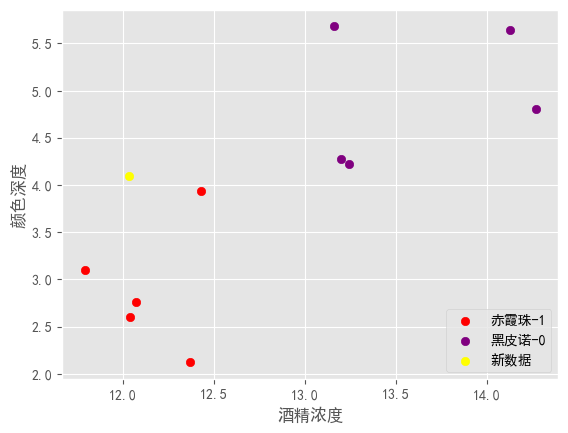

In [ ]:
#探索数据：假如我们给出新数据[12.03,4.1] ，你能猜出这杯红酒是什么类别吗？
new_data = np.array([12.03,4.1])

# 绘制散点图
plt.scatter(x[y==1,0], x[y==1,1], color='red', label='赤霞珠-1') #画出标签y为1的、关于“赤霞珠”的散点
plt.scatter(x[y==0,0], x[y==0,1], color='purple', label='黑皮诺-0') #画出标签y为0的、关于“黑皮诺”的散点
plt.scatter(new_data[0],new_data[1], color='yellow', label='新数据') # 未知测试集散点，单独颜色标注

new_data

# 设置散点图相关属性
plt.xlabel('酒精浓度')
plt.ylabel('颜色深度')
plt.legend(loc='lower right')

# 保存散点图
# plt.savefig('04th_KNN_葡萄酒样本.png')

In [5]:
# 导入数学模块
from math import sqrt

# 公式得自己写奥！
distance = [sqrt(np.sum((x_num - new_data) ** 2)) for x_num in x ] # 循环遍历
distance

[2.6041505332833594,
 1.1837651794169315,
 1.9424983912477256,
 2.3468276459936295,
 1.2159358535712326,
 1.3405968819895113,
 0.4308131845707605,
 1.0283968105745949,
 2.0089798406156287,
 1.500033332962971]

In [6]:
sort_dist = np.argsort(distance)
sort_dist

array([6, 7, 1, 4, 5, 9, 2, 8, 3, 0])

In [7]:
# 给定k值为3
k = 3
topK = [y[i] for i in sort_dist[:k]] # 从升序索引序列切片前3个样本，根据索引分别查看其标签（红酒品种类别）
topK
# 统计topK中每个类别出现的次数
from collections import Counter
Counter(topK)

[np.int64(1), np.int64(1), np.int64(0)]

Counter({np.int64(1): 2, np.int64(0): 1})

In [8]:
pd.Series(topK).value_counts()

1    2
0    1
Name: count, dtype: int64

In [9]:
pd.Series(topK).value_counts().index[0]

np.int64(1)

In [10]:
# KNN算法已经实现，接下来整合前述所有代码，构造一个可用的KNN分类器 - 函数封装所有功能，去除画图步骤即可
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 导入数学模块
from math import sqrt

# 这个对象设置所有行全部输出
from IPython.core.interactiveshell import InteractiveShell 

# 设置该对象ast_node_interactivity属性的值为all，表示在notebook下每一行有输出的代码全部输出运算结果
InteractiveShell.ast_node_interactivity = "all" 

# 解决坐标轴刻度负号乱码
plt.rcParams['axes.unicode_minus'] = False

# 解决中文乱码问题
plt.rcParams['font.sans-serif'] = ['Simhei']
plt.style.use('ggplot')

# 数据准备
rowdata = {
    '颜色深度':[14.13,13.2,13.16,14.27,13.24,12.07,12.43,11.79,12.37,12.04],
    '酒精浓度': [5.64,4.28,5.68,4.80,4.22,2.76,3.94,3.1,2.12,2.6],
    '品种': [0,0,0,0,0,1,1,1,1,1] # 0 代表 “黑皮诺”，1 代表 “赤霞珠”
}

# 构建为dataframe对象
wine_data = pd.DataFrame(rowdata)
wine_data

def KNN_alo(new_data,dataset,k):
    '''
    实现一个KNN分类器
    :params new_data:测试集
    :params dataset:已分类数据集
    :params k:超参数，距离最近的k个点
    :return:分类结果
    '''
    result = []
    
    X = np.array(wine_data.iloc[:,0:2])
    y = np.array(wine_data.iloc[:,-1])
    
    distance = [sqrt(np.sum((x_num - new_data) ** 2)) for x_num in X ] # 循环遍历
    sort_dist = np.argsort(distance)
    topK = [y[i] for i in sort_dist[:k]] # 从升序索引序列切片前3个样本，根据索引分别查看其标签（红酒品种类别）

    result.append(pd.Series(topK).value_counts().index[0])

    return result
    
# 测试函数的运行结果
new_data=np.array([12.03,4.1])
k = 3
print(KNN_alo(new_data,wine_data,k))

,颜色深度,酒精浓度,品种
0,14.13,5.64,0
1,13.20,4.28,0
2,13.16,5.68,0
3,14.27,4.80,0
4,13.24,4.22,0
5,12.07,2.76,1
6,12.43,3.94,1
7,11.79,3.10,1
8,12.37,2.12,1
9,12.04,2.60,1


[np.int64(1)]


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 从sklearn中导入KNN分类器
from sklearn.neighbors import KNeighborsClassifier

from IPython.core.interactiveshell import InteractiveShell # 这个对象设置所有行全部输出

# 设置该对象ast_node_interactivity属性的值为all，表示在notebook下每一行有输出的代码全部输出运算结果
InteractiveShell.ast_node_interactivity = "all" 

# 解决坐标轴刻度负号乱码
plt.rcParams['axes.unicode_minus'] = False

# 解决中文乱码问题
plt.rcParams['font.sans-serif'] = ['Simhei']
plt.style.use('ggplot')

In [12]:
# 数据准备
rowdata = {
    '颜色深度':[14.13,13.2,13.16,14.27,13.24,12.07,12.43,11.79,12.37,12.04],
    '酒精浓度': [5.64,4.28,5.68,4.80,4.22,2.76,3.94,3.1,2.12,2.6],
    '品种': [0,0,0,0,0,1,1,1,1,1] # 0 代表 “黑皮诺”，1 代表 “赤霞珠”
}

# 构建为dataframe对象
wine_data = pd.DataFrame(rowdata)
wine_data

,颜色深度,酒精浓度,品种
0,14.13,5.64,0
1,13.20,4.28,0
2,13.16,5.68,0
3,14.27,4.80,0
4,13.24,4.22,0
5,12.07,2.76,1
6,12.43,3.94,1
7,11.79,3.10,1
8,12.37,2.12,1
9,12.04,2.60,1


In [13]:
clf = KNeighborsClassifier(n_neighbors = 3)

In [14]:
# 在有监督学习中，给定特征X和标签y
clf = clf.fit(wine_data.iloc[:,0:2], wine_data.iloc[:,-1])

In [15]:
# 返回预测的标签
result = clf.predict([[12.8,4.1]])
result

d:\miniconda3\envs\PyTorch\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([0])

In [16]:
# 对模型进行一个评估，接口score返回预测的准确率
score = clf.score([[12.8,4.1]],[0])
score 

d:\miniconda3\envs\PyTorch\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


1.0

In [17]:
clf.predict_proba([[12.8,4.1]])

d:\miniconda3\envs\PyTorch\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([[0.66666667, 0.33333333]])

In [18]:
from sklearn.neighbors import KNeighborsClassifier

# 导入sklearn自带的美国威斯康辛州女性乳腺癌检测数据集
from sklearn.datasets import load_breast_cancer

# 划分数据集为训练集和测试集
from sklearn.model_selection import train_test_split

import pandas as pd
import numpy as np

In [19]:
# 读取数据集
data = load_breast_cancer()

# 构造DateFrame格式化显示数据
X = data.data
y = data.target

name = [
    '平均半径','平均纹理','平均周长','平均面积',
    '平均光滑度','平均紧凑度','平均凹度',
    '平均凹点','平均对称','平均分形维数',
    '半径误差','纹理误差','周长误差','面积误差',
    '平滑度误差','紧凑度误差','凹度误差',
    '凹点误差','对称误差',
    '分形维数误差','最差半径','最差纹理',
    '最差的边界','最差的区域','最差的平滑度',
    '最差的紧凑性','最差的凹陷','最差的凹点',
    '最差的对称性','最差的分形维数','患病否'
]

data = np.concat((X,y.reshape(-1,1)),axis = 1)
table = pd.DataFrame(data = data,columns = name)
table

,平均半径,平均纹理,平均周长,平均面积,平均光滑度,平均紧凑度,平均凹度,平均凹点,平均对称,平均分形维数,...,最差纹理,最差的边界,最差的区域,最差的平滑度,最差的紧凑性,最差的凹陷,最差的凹点,最差的对称性,最差的分形维数,患病否
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0.0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0.0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0.0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0.0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0.0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0.0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0.0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0.0


In [20]:
# 划分训练集和测试集 - 我们选择30%数据作为测试集
Xtrain,Xtest,Ytrain,Ytest = train_test_split(table.iloc[:,:-1],table.iloc[:,-1],test_size=0.3,random_state=420)
Xtrain.shape
Xtest.shape
Ytrain.shape
Ytest.shape

(398, 30)

(171, 30)

(398,)

(171,)

In [21]:
# 构建KNN分类器 - 指定k值为4
clf = KNeighborsClassifier(n_neighbors = 4)

In [22]:
# 调用估计器构建KNN模型
clf = clf.fit(Xtrain,Ytrain)

In [23]:
# 模型评估
score = clf.score(Xtest,Ytest)
score

0.9064327485380117

In [30]:
# 查找测试集中指定测试样本的K邻居 - 其会返回该测试样本的所有K个邻居与之的距离和每个邻居的索引
result = clf.kneighbors(Xtest.iloc[[20,30],:],return_distance=True)
result


(array([[35.70015941, 42.02374599, 81.82147557, 83.06271326],
        [11.81126721, 14.5871725 , 18.94892695, 22.82904215]]),
 array([[ 55, 164, 246, 206],
        [211, 105,  77, 359]]))

In [31]:
# -*- coding:utf-8 -*-

# Packages and Modules import statements
# --------------------------------------

# from torchvision import dataset of MNIST and transforms
from torchvision import datasets,transforms

import numpy as np

# import evaluation metrics of accyracy_score
from sklearn.metrics import accuracy_score

import torch

# import progress bar(进度条)
from tqdm import tqdm
from time import time,sleep


# codings
# --------------------------------------

# 1.download and load MNIST dataset and split for data and target
def load_and_split_dataset():

    # download and load train dataset,params of download=true means need download dataset first,params transform means need change data type from ndarray to tensor(张量)
    train_dataset = datasets.MNIST(
        root='./data',
        download=True,
        transform=transforms.ToTensor(),
        train=True
    )

    # download and load train dataset,params of download=true means need download dataset first,params transform means need change data type from ndarray to tensor(张量)
    test_dataset = datasets.MNIST(
        root='./data',
        download=True,
        transform=transforms.ToTensor(),
        train=False
    )

    # split data and target from train dataset
    train_x = []
    train_y = []

    # iter for each samples
    for i in range(len(train_dataset)):

        # get samples and target
        images,target = train_dataset[i]


        # append each samples to list
        train_x.append(images.view(-1)) # reshape tensor
        train_y.append(target)

        # only need 5000 train samples
        if i > 5000:
            break

    # split data and target from test dataset
    test_x = []
    test_y = []

    # iter for each samples
    for i in range(len(test_dataset)):

        # get samples and target
        images, target = test_dataset[i]


        # append each samples to list
        test_x.append(images.view(-1))  # reshape tensor
        test_y.append(target)

        # only need 200 test samples
        if i > 200:
            break

    print('samples all classes:{}'.format(set(train_y)))

    return train_x,train_y,test_x,test_y

# 2.define the KNN model
def KNN_Model(train_x,train_y,test_x,test_y,k):
    '''
    build the knn model
    :param train_x: train dataset
    :param train_y: train target(label)
    :param test_x: test dataset
    :param test_y: test target(label)
    :param k: neighbor counts
    :return:
    '''

    # get local timestamp
    since = time()

    # get train dataset and test dataset of samples number
    m = test_x.size(0)
    n = train_x.size(0)

    # test dataset and train dataset original(原本的) dimension(维度) is m*1,**2 is square(平方) for each samples,sum(dim=1,means sum for line(sample),keepdim=true means keep 2 dimension),expand means change the disension for keep m*n
    xx = (test_x ** 2).sum(dim=1, keepdim=True).expand(m, n)
    yy = (train_x ** 2).sum(dim=1, keepdim=True).expand(n, m).transpose(0, 1) # transpose means reshape(转置)

    # cal neighbors distance matrix
    dist_mat = xx + yy - 2 * test_x.matmul(train_x.transpose(0, 1)) # code means:(x-y)**2

    # sort for neighbors distance metrix,need to find which samples is the nearest neighbor
    mink_idxs = dist_mat.argsort(dim=-1)

    # empty list,to save k nums nearest neighbors
    res = []
    for idxs in mink_idxs:
        # voting
        res.append(np.bincount(np.array([train_y[idx] for idx in idxs[:k]])).argmax())

    # 断言调试，断定找到的k个最近的邻居的个数与测试集样本个数
    assert len(res) == len(test_y)

    # cal accuracy_score
    print("accuracy_score:{}".format(accuracy_score(test_y, res)))

    # cal training time
    time_elapsed = time() - since

    print('KNN mat training complete in {}m {}s'.format(time_elapsed // 60, time_elapsed % 60))

def test():
    train_x,train_y,test_x,test_y = load_and_split_dataset()
    KNN_Model(torch.stack(train_x), train_y, torch.stack(test_x), test_y, 7)

# run test UseCase if current modules is main
if __name__ == '__main__':
    test()

100%|██████████| 9.91M/9.91M [00:02<00:00, 3.86MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 112kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.02MB/s]
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]


samples all classes:{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
accuracy_score:0.9405940594059405
KNN mat training complete in 0.0m 0.042795658111572266s
